In [4]:
import json
import pandas as pd

# 웹에서 자료를 수집하는 방법
* 1. API를 이용해서 자료 수집
    * naver, google, kakao, 공공데이터에서 제공하는 API를 이용해서 자료 수집
* 2. Web페이지를 직접 스크래이핑 해서 자료 수집
    * 정적페이지 수집: javascript 없이 수집 가능한 사이트
    * 동적페이지 수집: javascript에 의해서 콘텐츠가 제어, 웹브라우저 제어를 통해 수집

## url: http://로 시작하는 웹페이지 접속 주소
* url: 실제 서비스 서버에 접속하는 주소
* parameter: 서비스에 요청하는 값


### 네이버책검색
ID: KWqT_uEHMFwBxZHzqvXj      <br>
PW: UaIJQBMlNd

In [27]:
# 네이버 검색 API 예제 - 블로그 검색

####################################################################
# 1. url 주소로 서버에 url과 parameter를 보냄
# 2. 서버로부터 응답을 받음
# 3, 응답코드가 200이면 출력
####################################################################

import os
import sys
import urllib.request

client_id = "KWqT_uEHMFwBxZHzqvXj"
client_secret = "UaIJQBMlNd"

encText = urllib.parse.quote("핀테크")   # parse.quote는 utf-8코드로 인코딩
url = "https://openapi.naver.com/v1/search/blog?query=" + encText # JSON 결과
# url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
# 블로그는 blog,json / 뉴스는 news.json / 백과사전은 encyc.json 등으로 구분


request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)

response = urllib.request.urlopen(request)
rescode = response.getcode()

if(rescode==200):      # 에러코드
    response_body = response.read()
    print(response_body.decode('utf-8'))  # 컴퓨터 언어 -> 한글로 디코딩 실행
else:
    print("Error Code:" + rescode)

{
	"lastBuildDate":"Mon, 31 Mar 2025 14:33:52 +0900",
	"total":456077,
	"start":1,
	"display":10,
	"items":[
		{
			"title":"<b>핀테크<\/b> 투자 후기",
			"link":"https:\/\/blog.naver.com\/kan1687\/223812724931",
			"description":"<b>핀테크<\/b> 투자, 아직도 망설이고 계신가요?  여러분 혹시 이런 고민 해보신 적 있나요? &quot;<b>핀테크<\/b> 분야가 떴다는데, 지금 시작해도 괜찮을까? 좀 더 상황을 지켜봐야 하나?&quot; 사실 이런 생각은 투자를 고민하는 우리... ",
			"bloggername":"우정잉♥",
			"bloggerlink":"blog.naver.com\/kan1687",
			"postdate":"20250329"
		},
		{
			"title":"[<b>핀테크<\/b>] 2024년 <b>핀테크<\/b> 업계 결산: 놀라운 3가지 변화",
			"link":"https:\/\/blog.naver.com\/xoom777\/223708685044",
			"description":"동안 <b>핀테크<\/b> 업계에는 예상치 못한 변화의 바람이 불었습니다. 한동안 주춤했던 트렌드가... 올 한 해 <b>핀테크<\/b> 업계를 뜨겁게 달군 3가지 트렌드에 대해 자세히 살펴보겠습니다. 암호화폐의 귀환, 기관... ",
			"bloggername":"Ich fange an",
			"bloggerlink":"blog.naver.com\/xoom777",
			"postdate":"20241229"
		},
		{
			"title":"[인사이트 캠퍼스] 2025 동계 <b>핀테크<\/b> 캠프 (with 전주대학교... ",
			"link":"https:\/\/blog.naver.com\/fininsight\/223734638126",
			"descri

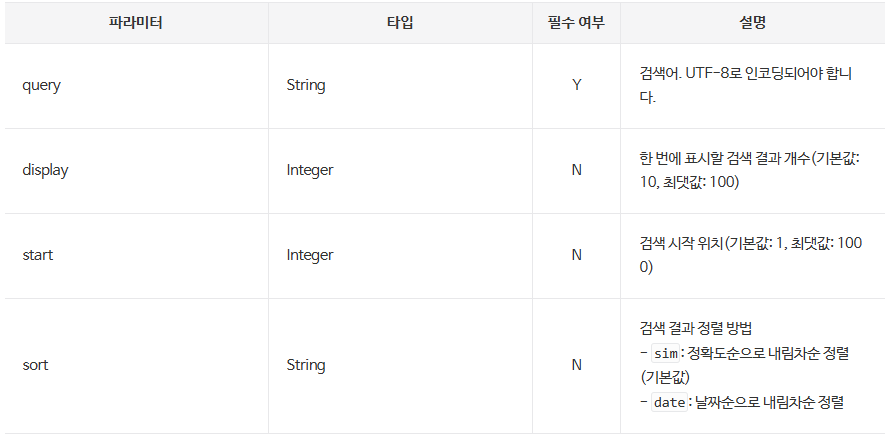
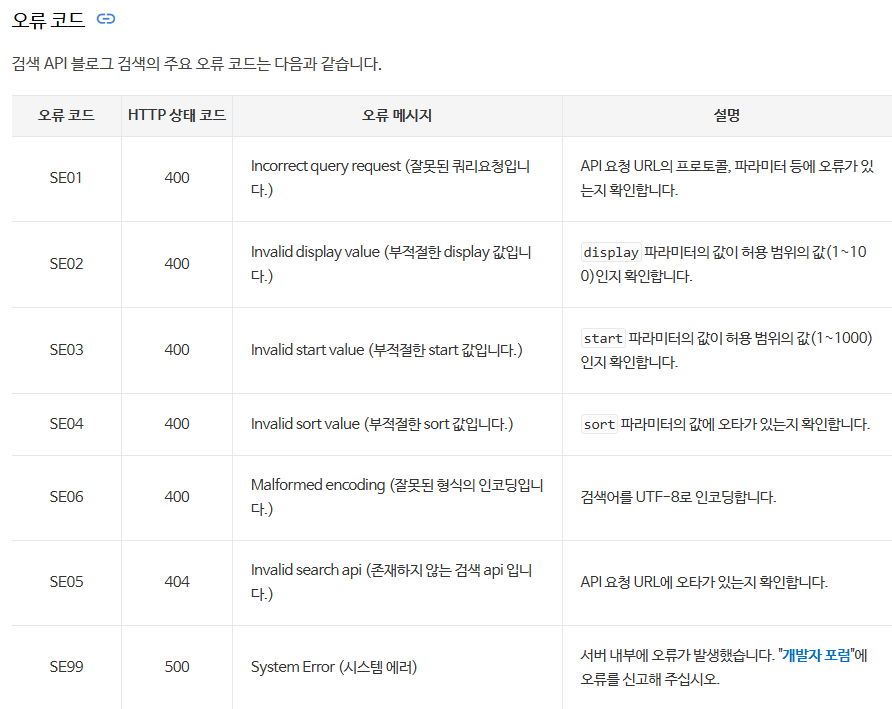

In [28]:
data = response_body.decode('utf-8')

In [29]:
data = json.loads(data)

In [30]:
request = {}
for item in data['items']:
    for key, value in item.items():
        request.setdefault(key, []).append(value)

request_df = pd.DataFrame(request)

In [31]:
request_df

,title,link,description,bloggername,bloggerlink,postdate
0,<b>핀테크</b> 투자 후기,https://blog.naver.com/kan1687/223812724931,"<b>핀테크</b> 투자, 아직도 망설이고 계신가요? 여러분 혹시 이런 고민 해보...",우정잉♥,blog.naver.com/kan1687,20250329
1,[<b>핀테크</b>] 2024년 <b>핀테크</b> 업계 결산: 놀라운 3가지 변화,https://blog.naver.com/xoom777/223708685044,동안 <b>핀테크</b> 업계에는 예상치 못한 변화의 바람이 불었습니다. 한동안 주...,Ich fange an,blog.naver.com/xoom777,20241229
2,[인사이트 캠퍼스] 2025 동계 <b>핀테크</b> 캠프 (with 전주대학교...,https://blog.naver.com/fininsight/223734638126,전주대학교 친구들이 직접 여의도까지 방문하여 <b>핀테크</b>(FinTech)의 ...,핀인사이트 (Fininsight),blog.naver.com/fininsight,20250122
3,[AI <b>핀테크</b>] AI와 빅데이터로 금융 시장을 재편하는 <b>핀테크</...,https://blog.naver.com/jangpung_/223765345858,이제 대출도 AI가 하는 시대 출처 : 파가야 테크놀러지스 홈페이지 금융과 기술이 ...,낭만을 꿈꾸는 일상,blog.naver.com/jangpung_,20250218
4,IPAY <b>핀테크</b>관련주 ETF -미국 CBDC 코인 서비스 실험 확대,https://blog.naver.com/jaso_/223736810791,IPAY <b>핀테크</b>관련주 ETF -미국 CBDC 코인 서비스 실험 확대 I...,미국주식 퍼주마,blog.naver.com/jaso_,20250130
5,맨틀 MNT 코인 디파이 <b>핀테크</b> 서비스 소개,https://blog.naver.com/tmglove/223781181469,웹2와 웹3을 아우르며 기관과 개인 그리고 리테일을 위한 다양한 <b>핀테크</b>...,Hello-,blog.naver.com/tmglove,20250302
6,[<b>핀테크</b> 리더] # 2024 금융위원회 선정 10대 기업 _ 1편,https://blog.naver.com/koreafintech/223675560515,[<b>핀테크</b> 리더] ⭐ # 2024 금융위원회 선정 10대 기업 _ 1편 ...,한국핀테크지원센터,blog.naver.com/koreafintech,20241128
7,맨틀 네트워크 코인 MNT <b>핀테크</b> 서비스 등장,https://blog.naver.com/ghfjvb465/223781841217,"맨틀네트워크 코인 <b>핀테크</b>와 크립토 경계 허물기 소개, 시세, 전망 코하...",노마드신지테의 경제적자유얻기 챌린지,blog.naver.com/ghfjvb465,20250303
8,신규 상장 더즌 <b>핀테크</b> B2B 기업용 금융통신망 쉿 쉿 조용 조용,https://blog.naver.com/2yongki/223805949459,기업 개요 20017년 설립 기업용 금융 통신망 서비스를 제공하는 <b>핀테크</b...,행복한남 경제야놀자,blog.naver.com/2yongki,20250323
9,테크놀로지스(PGY): AI 기반 대출 혁신의 주목받는 <b>핀테크</b> 기업,https://blog.naver.com/an5217/223810108719,최근 <b>핀테크</b> 업계에서 주목받는 기업 **파가야 테크놀로지스(NASDAQ...,오늘 하루도 절도있고 검소하게,blog.naver.com/an5217,20250326
